**Perguntas para ser respondidas na análise**

1. Adequação do nível (IAN)
Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?
(Ex.: quantos alunos estão moderadamente ou severamente defasados?)

2. Desempenho acadêmico (IDA)
O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

3. Engajamento nas atividades (IEG)
O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

4. Autoavaliação (IAA)
As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

5. Aspectos psicossociais (IPS)
Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

6. Aspectos psicopedagógicos (IPP)
As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

7. Ponto de virada (IPV)
Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

8. Multidimensionalidade dos indicadores
Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

9. Previsão de risco com Machine Learning
Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.

10. Efetividade do programa
Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

11. Insights e criatividade
Você pode adicionar mais insights e pontos de vista não abordados nas perguntas, utilize a criatividade e a análise dos dados para trazer sugestões para a Passos Mágicos.

In [403]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint

In [404]:
dados = '/content/BASE DE DADOS PEDE 2024 - DATATHON.xlsx'

In [405]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', None)

In [406]:
df_2022 = pd.read_excel(dados, sheet_name='PEDE2022')
df_2023 = pd.read_excel(dados, sheet_name='PEDE2023')
df_2024 = pd.read_excel(dados, sheet_name='PEDE2024')

In [407]:
df_2022_limpo = df_2022.drop(columns=['RA', 'Turma', 'Nome', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV','Avaliador1', 'Avaliador2', 'Avaliador3', 'Avaliador4','Nº Av', 'Indicado', 'Fase ideal', 'Rec Av1', 'Rec Av2', 'Rec Av3', 'Rec Av4', 'Rec Psicologia', 'Cg', 'Cf', 'Ct', 'Atingiu PV', 'Fase'])

In [408]:
df_2022_limpo.rename(columns={'Idade 22':'Idade',
                              'INDE 22':'INDE_Indice_Desenv_Educacional',
                              'IAA':'IAA_Indice_Autoavaliacao',
                              'IEG':'IEG_Indice_Engajamento',
                              'IPS':'IPS_Indice_Psicossocial',
                              'IDA':'IDA_Indice_Desempenho_Academico',
                              'IAN':'IAN_Indice_Adequacao_Nivel',
                              'IPV':'IPV_Indice_Ponto_Virada',
                              'Defas':'Defasagem',
                              'Matem':'Matematica',
                              'Portug':'Portugues',
                              'Inglês':'Ingles'}, inplace=True)

In [409]:
print(df_2022_limpo.head(2))

   Ano nasc  Idade  Gênero  Ano ingresso Instituição de ensino  INDE_Indice_Desenv_Educacional  IAA_Indice_Autoavaliacao  IEG_Indice_Engajamento  IPS_Indice_Psicossocial  IDA_Indice_Desempenho_Academico  Matematica  Portugues  Ingles  IPV_Indice_Ponto_Virada  IAN_Indice_Adequacao_Nivel  Defasagem
0      2003     19  Menina          2016        Escola Pública                           5.783                       8.3                     4.1                      5.6                              4.0         2.7        3.5     6.0                    7.278                         5.0         -1
1      2005     17  Menina          2017          Rede Decisão                           7.055                       8.8                     5.2                      6.3                              6.8         6.3        4.5     9.7                    6.778                        10.0          0


In [410]:
print(df_2023.head(2))

       RA  Fase  INDE 2023 Pedra 2023           Turma Nome Anonimizado Data de Nasc Idade     Gênero  Ano ingresso Instituição de ensino Pedra 20 Pedra 21 Pedra 22  Pedra 23  INDE 22  INDE 23  Cg  Cf  Ct  Nº Av    Avaliador1  Rec Av1   Avaliador2  Rec Av2 Avaliador3  Rec Av3 Avaliador4  Rec Av4  IAA   IEG   IPS     IPP  Rec Psicologia  IDA  Mat  Por  Ing  Indicado  Atingiu PV    IPV   IAN            Fase Ideal  Defasagem  Destaque IEG  Destaque IDA  Destaque IPV  Destaque IPV.1
0  RA-861  ALFA    9.31095    Topázio  ALFA A - G0/G1        Aluno-861    6/17/2015     8   Feminino          2023               Pública      NaN      NaN      NaN       NaN      NaN      NaN NaN NaN NaN    2.0  Avaliador-11      NaN  Avaliador-2      NaN        NaN      NaN        NaN      NaN  9.5  10.0  8.13  8.4375             NaN  9.6  9.8  9.4  NaN       NaN         NaN  8.920  10.0    ALFA (1° e 2° ano)          0           NaN           NaN           NaN             NaN
1  RA-862  ALFA    8.22120    Topá

In [411]:
df_2023_limpo = df_2023.drop(columns=['RA', 'Turma', 'Nome Anonimizado', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'Nº Av', 'Avaliador1', 'Avaliador2', 'Avaliador3', 'Avaliador4', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'Indicado', 'Atingiu PV', 'INDE 22', 'INDE 23', 'Rec Psicologia', 'Rec Av1', 'Rec Av2', 'Cg', 'Cf', 'Ct', 'Fase Ideal', 'IPP', 'Pedra 2023', 'Rec Av3', 'Rec Av4', 'Destaque IPV.1', 'Fase'])

In [412]:
df_2023_limpo.rename(columns={'INDE 2023':'INDE_Indice_Desenv_Educacional',
                              'IAA':'IAA_Indice_Autoavaliacao',
                              'IEG':'IEG_Indice_Engajamento',
                              'IPS':'IPS_Indice_Psicossocial',
                              'IDA':'IDA_Indice_Desempenho_Academico',
                              'IAN':'IAN_Indice_Adequacao_Nivel',
                              'Defas':'Defasagem',
                              'Data de Nasc':'nasc',
                              'IPP':'IPP_Indice_Psicopedagogico',
                              'Mat':'Matematica',
                              'Por':'Portugues',
                              'Ing':'Ingles',
                              'IPV':'IPV_Indice_Ponto_Virada'}, inplace=True)

In [413]:
df_2023_limpo['nasc'] = pd.to_datetime(df_2023_limpo['nasc'])
df_2023_limpo['Ano nasc'] = df_2023_limpo['nasc'].dt.year

In [414]:
df_2023_limpo.drop(['nasc'], axis=1, inplace=True)

In [415]:
print(df_2023_limpo.head(2))

   INDE_Indice_Desenv_Educacional Idade     Gênero  Ano ingresso Instituição de ensino  IAA_Indice_Autoavaliacao  IEG_Indice_Engajamento  IPS_Indice_Psicossocial  IDA_Indice_Desempenho_Academico  Matematica  Portugues  Ingles  IPV_Indice_Ponto_Virada  IAN_Indice_Adequacao_Nivel  Defasagem  Ano nasc
0                         9.31095     8   Feminino          2023               Pública                       9.5                    10.0                     8.13                              9.6         9.8        9.4     NaN                    8.920                        10.0          0      2015
1                         8.22120     9  Masculino          2023               Pública                       8.5                     9.1                     8.14                              8.9         8.5        9.2     NaN                    8.585                         5.0         -1      2014


In [416]:
df_2024_limpo = df_2024.drop(columns=['RA', 'Turma', 'Pedra 2024', 'Nome Anonimizado', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'Nº Av', 'Avaliador1', 'Avaliador2', 'Avaliador3', 'Avaliador4', 'Avaliador5', 'Avaliador6', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'Escola', 'Ativo/ Inativo', 'Ativo/ Inativo.1', 'Indicado', 'Atingiu PV', 'INDE 22', 'INDE 23', 'Rec Psicologia', 'Rec Av1', 'Rec Av2', 'Cg', 'Cf', 'Ct', 'Fase Ideal', 'IPP', 'Fase'])

In [417]:
df_2024_limpo.rename(columns={'INDE 2024':'INDE_Indice_Desenv_Educacional',
                              'IAA':'IAA_Indice_Autoavaliacao',
                              'IEG':'IEG_Indice_Engajamento',
                              'IPS':'IPS_Indice_Psicossocial',
                              'IDA':'IDA_Indice_Desempenho_Academico',
                              'IAN':'IAN_Indice_Adequacao_Nivel',
                              'Defas':'Defasagem',
                              'Data de Nasc':'nasc',
                              'IPP':'IPP_Indice_Psicopedagogico',
                              'Mat':'Matematica',
                              'Por':'Portugues',
                              'Ing':'Ingles',
                              'IPV':'IPV_Indice_Ponto_Virada'}, inplace=True)

In [418]:
df_2024_limpo['nasc'] = pd.to_datetime(df_2024_limpo['nasc'])
df_2024_limpo['Ano nasc'] = df_2024_limpo['nasc'].dt.year

In [419]:
df_2024_limpo.drop(['nasc'], axis=1, inplace=True)

In [420]:
print(df_2024_limpo.head(10))

  INDE_Indice_Desenv_Educacional  Idade     Gênero  Ano ingresso Instituição de ensino  IAA_Indice_Autoavaliacao  IEG_Indice_Engajamento  IPS_Indice_Psicossocial  IDA_Indice_Desempenho_Academico  Matematica  Portugues  Ingles  IPV_Indice_Ponto_Virada  IAN_Indice_Adequacao_Nivel  Defasagem  Ano nasc
0                       7.611367      8  Masculino          2024               Pública                    10.002                8.666667                     6.26                             8.00        10.0        6.0     NaN                 5.446667                        10.0          0      2016
1                       8.002867      8   Feminino          2024               Pública                    10.002                9.333333                     3.76                             8.00        10.0        6.0     NaN                 7.050000                        10.0          0      2016
2                         7.9522      8  Masculino          2024               Pública              

In [421]:
df_2022_limpo.shape

(860, 16)

In [422]:
df_2023_limpo.shape

(1014, 16)

In [423]:
df_2024_limpo.shape

(1156, 16)

In [424]:
df_2022_limpo.columns.to_list()

['Ano nasc',
 'Idade',
 'Gênero',
 'Ano ingresso',
 'Instituição de ensino',
 'INDE_Indice_Desenv_Educacional',
 'IAA_Indice_Autoavaliacao',
 'IEG_Indice_Engajamento',
 'IPS_Indice_Psicossocial',
 'IDA_Indice_Desempenho_Academico',
 'Matematica',
 'Portugues',
 'Ingles',
 'IPV_Indice_Ponto_Virada',
 'IAN_Indice_Adequacao_Nivel',
 'Defasagem']

In [425]:
df_2023_limpo.columns.to_list()

['INDE_Indice_Desenv_Educacional',
 'Idade',
 'Gênero',
 'Ano ingresso',
 'Instituição de ensino',
 'IAA_Indice_Autoavaliacao',
 'IEG_Indice_Engajamento',
 'IPS_Indice_Psicossocial',
 'IDA_Indice_Desempenho_Academico',
 'Matematica',
 'Portugues',
 'Ingles',
 'IPV_Indice_Ponto_Virada',
 'IAN_Indice_Adequacao_Nivel',
 'Defasagem',
 'Ano nasc']

In [426]:
df_2024_limpo.columns.to_list()

['INDE_Indice_Desenv_Educacional',
 'Idade',
 'Gênero',
 'Ano ingresso',
 'Instituição de ensino',
 'IAA_Indice_Autoavaliacao',
 'IEG_Indice_Engajamento',
 'IPS_Indice_Psicossocial',
 'IDA_Indice_Desempenho_Academico',
 'Matematica',
 'Portugues',
 'Ingles',
 'IPV_Indice_Ponto_Virada',
 'IAN_Indice_Adequacao_Nivel',
 'Defasagem',
 'Ano nasc']

In [427]:
ordem_colunas = ['Ano nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'IAA_Indice_Autoavaliacao', 'IEG_Indice_Engajamento', 'IPS_Indice_Psicossocial', 'IDA_Indice_Desempenho_Academico', 'IPV_Indice_Ponto_Virada', 'IAN_Indice_Adequacao_Nivel', 'INDE_Indice_Desenv_Educacional', 'Matematica', 'Portugues', 'Ingles', 'Defasagem']

In [428]:
df_2022_limpo[ordem_colunas]

,Ano nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,IAA_Indice_Autoavaliacao,IEG_Indice_Engajamento,IPS_Indice_Psicossocial,IDA_Indice_Desempenho_Academico,IPV_Indice_Ponto_Virada,IAN_Indice_Adequacao_Nivel,INDE_Indice_Desenv_Educacional,Matematica,Portugues,Ingles,Defasagem
0,2003,19,Menina,2016,Escola Pública,8.3,4.1,5.6,4.0,7.278,5.0,5.783,2.7,3.5,6.0,-1
1,2005,17,Menina,2017,Rede Decisão,8.8,5.2,6.3,6.8,6.778,10.0,7.055,6.3,4.5,9.7,0
2,2005,17,Menina,2016,Rede Decisão,0.0,7.9,5.6,5.6,7.556,10.0,6.591,5.8,4.0,6.9,0
3,2005,17,Menino,2017,Rede Decisão,8.8,4.5,5.6,5.0,5.278,10.0,5.951,2.8,3.5,8.7,0
4,2005,17,Menina,2016,Rede Decisão,7.9,8.6,5.6,5.2,7.389,10.0,7.427,7.0,2.9,5.7,0
5,2004,18,Menina,2021,Escola Pública,7.9,4.5,7.5,3.3,7.222,5.0,5.848,2.3,5.3,2.3,-1
6,2004,18,Menino,2017,Rede Decisão,0.0,8.4,7.5,7.6,7.667,5.0,6.818,8.2,5.7,9.0,-1
7,2002,20,Menina,2018,Escola Pública,7.1,4.6,6.3,1.6,6.278,5.0,4.786,1.2,0.7,2.9,-1
8,2004,18,Menina,2019,Escola Pública,8.8,9.5,7.5,6.7,9.500,5.0,8.109,5.5,6.0,8.7,-1
9,2004,18,Menina,2021,Escola Pública,8.3,5.2,5.0,4.1,7.056,5.0,5.784,3.3,2.6,6.4,-1


In [429]:
df_2023_limpo[ordem_colunas]

,Ano nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,IAA_Indice_Autoavaliacao,IEG_Indice_Engajamento,IPS_Indice_Psicossocial,IDA_Indice_Desempenho_Academico,IPV_Indice_Ponto_Virada,IAN_Indice_Adequacao_Nivel,INDE_Indice_Desenv_Educacional,Matematica,Portugues,Ingles,Defasagem
0,2015,8,Feminino,2023,Pública,9.5,10.0,8.13,9.6,8.920000,10.0,9.310950,9.8,9.4,NaN,0
1,2014,9,Masculino,2023,Pública,8.5,9.1,8.14,8.9,8.585000,5.0,8.221200,8.5,9.2,NaN,-1
2,2016,7,Masculino,2023,Pública,0.0,7.6,3.14,6.3,6.260000,10.0,5.929750,7.0,5.5,NaN,0
3,2015,1900-01-08 00:00:00,Feminino,2023,Pública,0.0,7.6,8.14,6.3,8.500000,10.0,7.034000,7.0,5.5,NaN,0
4,2014,8,Masculino,2023,Pública,8.5,8.7,7.52,7.4,7.915000,10.0,8.155200,7.3,7.5,NaN,0
5,2016,1900-01-07 00:00:00,Feminino,2023,Pública,0.0,8.3,8.76,8.6,8.415000,10.0,7.679000,8.2,8.9,NaN,0
6,2015,8,Masculino,2023,Pública,9.0,8.6,8.76,8.9,8.415000,10.0,8.699200,8.7,9.0,NaN,0
7,2015,1900-01-07 00:00:00,Masculino,2023,Pública,10.0,9.5,8.76,7.1,8.670000,10.0,8.638950,7.8,6.3,NaN,0
8,2015,8,Feminino,2023,Pública,9.0,10.0,8.76,9.6,8.750000,10.0,9.258700,9.8,9.4,NaN,0
9,2014,9,Feminino,2023,Pública,0.0,8.5,8.76,1.5,5.165000,5.0,4.909000,2.0,1.0,NaN,-1


In [430]:
df_2024_limpo[ordem_colunas]

,Ano nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,IAA_Indice_Autoavaliacao,IEG_Indice_Engajamento,IPS_Indice_Psicossocial,IDA_Indice_Desempenho_Academico,IPV_Indice_Ponto_Virada,IAN_Indice_Adequacao_Nivel,INDE_Indice_Desenv_Educacional,Matematica,Portugues,Ingles,Defasagem
0,2016,8,Masculino,2024,Pública,10.002,8.666667,6.2600,8.000000,5.446667,10.0,7.611367,10.00,6.00,NaN,0
1,2016,8,Feminino,2024,Pública,10.002,9.333333,3.7600,8.000000,7.050000,10.0,8.002867,10.00,6.00,NaN,0
2,2016,8,Masculino,2024,Pública,10.002,9.083333,3.7600,8.000000,7.046667,10.0,7.9522,10.00,6.00,NaN,0
3,2015,8,Masculino,2023,Pública,8.002,9.750000,3.7600,7.000000,7.213333,5.0,7.156367,8.00,6.00,NaN,-1
4,2015,9,Masculino,2024,Pública,9.002,4.166667,3.7600,7.500000,4.173333,5.0,5.4442,8.00,7.00,NaN,-1
5,2015,9,Feminino,2024,Pública,10.002,10.000000,6.2600,8.250000,7.780000,5.0,8.0822,9.00,7.50,NaN,-1
6,2015,9,Feminino,2023,Pública,9.502,10.000000,7.5100,10.000000,9.730000,5.0,8.9597,10.00,10.00,NaN,-1
7,2014,10,Masculino,2023,Pública,9.002,8.613636,7.5100,7.500000,6.270000,5.0,7.346677,10.00,5.00,NaN,-2
8,2015,9,Masculino,2024,Pública,10.002,9.545455,6.2600,8.500000,8.336667,5.0,8.152624,10.00,7.00,NaN,-1
9,2015,9,Feminino,2024,Pública,7.918,9.545455,6.2600,9.250000,7.780000,5.0,7.982891,10.00,8.50,NaN,-1


In [431]:
df = pd.concat([df_2022_limpo, df_2023_limpo, df_2024_limpo])

In [432]:
print(df.head(10))

   Ano nasc Idade  Gênero  Ano ingresso Instituição de ensino INDE_Indice_Desenv_Educacional  IAA_Indice_Autoavaliacao  IEG_Indice_Engajamento  IPS_Indice_Psicossocial  IDA_Indice_Desempenho_Academico  Matematica  Portugues  Ingles  IPV_Indice_Ponto_Virada  IAN_Indice_Adequacao_Nivel  Defasagem
0      2003    19  Menina          2016        Escola Pública                          5.783                       8.3                     4.1                      5.6                              4.0         2.7        3.5     6.0                    7.278                         5.0         -1
1      2005    17  Menina          2017          Rede Decisão                          7.055                       8.8                     5.2                      6.3                              6.8         6.3        4.5     9.7                    6.778                        10.0          0
2      2005    17  Menina          2016          Rede Decisão                          6.591                    

In [433]:
set(df['Gênero'])

{'Feminino', 'Masculino', 'Menina', 'Menino'}

In [434]:
genero = {'Feminino':0, 'Masculino':1, 'Menina':0, 'Menino':1}

In [435]:
df['Gênero'] = df['Gênero'].replace(genero)

/tmp/ipykernel_2550/3486436047.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gênero'] = df['Gênero'].replace(genero)


In [436]:
set(df['Idade'])

{10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 datetime.datetime(1900, 1, 7, 0, 0),
 datetime.datetime(1900, 1, 8, 0, 0),
 datetime.datetime(1900, 1, 9, 0, 0),
 datetime.datetime(1900, 1, 10, 0, 0),
 datetime.datetime(1900, 1, 11, 0, 0),
 datetime.datetime(1900, 1, 12, 0, 0),
 datetime.datetime(1900, 1, 13, 0, 0),
 datetime.datetime(1900, 1, 14, 0, 0),
 datetime.datetime(1900, 1, 15, 0, 0),
 datetime.datetime(1900, 1, 16, 0, 0),
 datetime.datetime(1900, 1, 17, 0, 0),
 datetime.datetime(1900, 1, 18, 0, 0),
 datetime.datetime(1900, 1, 19, 0, 0),
 datetime.datetime(1900, 1, 20, 0, 0),
 datetime.datetime(1900, 1, 21, 0, 0),
 datetime.datetime(1900, 1, 26, 0, 0),
 20,
 21,
 22,
 23,
 24,
 25,
 27,
 7,
 8,
 9}

In [437]:
import datetime

In [438]:
df['Idade'] = df['Idade'].apply(
    lambda x: (x - datetime.datetime(1899, 12, 31)).days
    if isinstance(x, datetime.datetime)
    else x
)

In [439]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3030 entries, 0 to 1155
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ano nasc                         3030 non-null   int64  
 1   Idade                            3030 non-null   int64  
 2   Gênero                           3030 non-null   int64  
 3   Ano ingresso                     3030 non-null   int64  
 4   Instituição de ensino            3029 non-null   object 
 5   INDE_Indice_Desenv_Educacional   2883 non-null   object 
 6   IAA_Indice_Autoavaliacao         2865 non-null   float64
 7   IEG_Indice_Engajamento           2954 non-null   float64
 8   IPS_Indice_Psicossocial          2859 non-null   float64
 9   IDA_Indice_Desempenho_Academico  2852 non-null   float64
 10  Matematica                       2846 non-null   float64
 11  Portugues                        2845 non-null   float64
 12  Ingles                   

In [440]:
df.isnull().sum()

,0
Ano nasc,0
Idade,0
Gênero,0
Ano ingresso,0
Instituição de ensino,1
INDE_Indice_Desenv_Educacional,147
IAA_Indice_Autoavaliacao,165
IEG_Indice_Engajamento,76
IPS_Indice_Psicossocial,171
IDA_Indice_Desempenho_Academico,178


In [441]:
df = df.fillna(0)

In [442]:
df.isnull().sum()

,0
Ano nasc,0
Idade,0
Gênero,0
Ano ingresso,0
Instituição de ensino,0
INDE_Indice_Desenv_Educacional,0
IAA_Indice_Autoavaliacao,0
IEG_Indice_Engajamento,0
IPS_Indice_Psicossocial,0
IDA_Indice_Desempenho_Academico,0


In [443]:
df['INDE_Indice_Desenv_Educacional'] = (df['INDE_Indice_Desenv_Educacional'].replace('INCLUIR', 0).astype(float))

/tmp/ipykernel_2550/4266147344.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['INDE_Indice_Desenv_Educacional'] = (df['INDE_Indice_Desenv_Educacional'].replace('INCLUIR', 0).astype(float))


In [444]:
df['INDE_Indice_Desenv_Educacional'] = df['INDE_Indice_Desenv_Educacional'].round(0)
df['IAA_Indice_Autoavaliacao'] = df['IAA_Indice_Autoavaliacao'].round(0)
df['IEG_Indice_Engajamento'] = df['IEG_Indice_Engajamento'].round(0)
df['IPS_Indice_Psicossocial'] = df['IPS_Indice_Psicossocial'].round(0)
df['IDA_Indice_Desempenho_Academico'] = df['IDA_Indice_Desempenho_Academico'].round(0)
df['Matematica'] = df['Matematica'].round(0)
df['Portugues'] = df['Portugues'].round(0)
df['Ingles'] = df['Ingles'].round(0)
df['IPV_Indice_Ponto_Virada'] = df['IPV_Indice_Ponto_Virada'].round(0)

In [445]:
print(df.head(10))

   Ano nasc  Idade  Gênero  Ano ingresso Instituição de ensino  INDE_Indice_Desenv_Educacional  IAA_Indice_Autoavaliacao  IEG_Indice_Engajamento  IPS_Indice_Psicossocial  IDA_Indice_Desempenho_Academico  Matematica  Portugues  Ingles  IPV_Indice_Ponto_Virada  IAN_Indice_Adequacao_Nivel  Defasagem
0      2003     19       0          2016        Escola Pública                             6.0                       8.0                     4.0                      6.0                              4.0         3.0        4.0     6.0                      7.0                         5.0         -1
1      2005     17       0          2017          Rede Decisão                             7.0                       9.0                     5.0                      6.0                              7.0         6.0        4.0    10.0                      7.0                        10.0          0
2      2005     17       0          2016          Rede Decisão                             7.0            

In [446]:
set(df['Instituição de ensino'])

{0,
 'Bolsista Universitário *Formado (a)',
 'Concluiu o 3º EM',
 'Escola JP II',
 'Escola Pública',
 'Nenhuma das opções acima',
 'Privada',
 'Privada *Parcerias com Bolsa 100%',
 'Privada - Pagamento por *Empresa Parceira',
 'Privada - Programa de Apadrinhamento',
 'Privada - Programa de apadrinhamento',
 'Pública',
 'Rede Decisão'}

In [447]:
set(df['Ano nasc'])

{1996,
 1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017}

In [448]:
set(df['Ano ingresso'])

{2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024}

In [449]:
set(df['Gênero'])

{0, 1}

In [450]:
set(df['Idade'])

{7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27}

In [451]:
from sklearn.preprocessing import LabelEncoder

In [452]:
le = LabelEncoder()

In [453]:
df['Instituição de ensino'] = df['Instituição de ensino'].astype(str)

In [454]:
df['Instituição_ensino_encoder'] = le.fit_transform(df['Instituição de ensino'])

In [455]:
print(df.head(10))

   Ano nasc  Idade  Gênero  Ano ingresso Instituição de ensino  INDE_Indice_Desenv_Educacional  IAA_Indice_Autoavaliacao  IEG_Indice_Engajamento  IPS_Indice_Psicossocial  IDA_Indice_Desempenho_Academico  Matematica  Portugues  Ingles  IPV_Indice_Ponto_Virada  IAN_Indice_Adequacao_Nivel  Defasagem  Instituição_ensino_encoder
0      2003     19       0          2016        Escola Pública                             6.0                       8.0                     4.0                      6.0                              4.0         3.0        4.0     6.0                      7.0                         5.0         -1                           4
1      2005     17       0          2017          Rede Decisão                             7.0                       9.0                     5.0                      6.0                              7.0         6.0        4.0    10.0                      7.0                        10.0          0                          12
2      2005     17    

In [456]:
colunas_verificacao = df[['Instituição de ensino', 'Instituição_ensino_encoder']]

In [457]:
print(colunas_verificacao)

                          Instituição de ensino  Instituição_ensino_encoder
0                                Escola Pública                           4
1                                  Rede Decisão                          12
2                                  Rede Decisão                          12
3                                  Rede Decisão                          12
4                                  Rede Decisão                          12
5                                Escola Pública                           4
6                                  Rede Decisão                          12
7                                Escola Pública                           4
8                                Escola Pública                           4
9                                Escola Pública                           4
10                               Escola Pública                           4
11                               Escola Pública                           4
12          

In [458]:
colunas_encoder = colunas_verificacao.groupby(['Instituição de ensino', 'Instituição_ensino_encoder'])

In [459]:
pd.set_option('display.max_rows', None)

In [460]:
print(colunas_encoder.head(100))

                          Instituição de ensino  Instituição_ensino_encoder
0                                Escola Pública                           4
1                                  Rede Decisão                          12
2                                  Rede Decisão                          12
3                                  Rede Decisão                          12
4                                  Rede Decisão                          12
5                                Escola Pública                           4
6                                  Rede Decisão                          12
7                                Escola Pública                           4
8                                Escola Pública                           4
9                                Escola Pública                           4
10                               Escola Pública                           4
11                               Escola Pública                           4
12          

In [461]:
df = df.drop('Instituição de ensino', axis=1)

In [462]:
print(df.head(10))

   Ano nasc  Idade  Gênero  Ano ingresso  INDE_Indice_Desenv_Educacional  IAA_Indice_Autoavaliacao  IEG_Indice_Engajamento  IPS_Indice_Psicossocial  IDA_Indice_Desempenho_Academico  Matematica  Portugues  Ingles  IPV_Indice_Ponto_Virada  IAN_Indice_Adequacao_Nivel  Defasagem  Instituição_ensino_encoder
0      2003     19       0          2016                             6.0                       8.0                     4.0                      6.0                              4.0         3.0        4.0     6.0                      7.0                         5.0         -1                           4
1      2005     17       0          2017                             7.0                       9.0                     5.0                      6.0                              7.0         6.0        4.0    10.0                      7.0                        10.0          0                          12
2      2005     17       0          2016                             7.0                

In [463]:
df.columns.to_list()

['Ano nasc',
 'Idade',
 'Gênero',
 'Ano ingresso',
 'INDE_Indice_Desenv_Educacional',
 'IAA_Indice_Autoavaliacao',
 'IEG_Indice_Engajamento',
 'IPS_Indice_Psicossocial',
 'IDA_Indice_Desempenho_Academico',
 'Matematica',
 'Portugues',
 'Ingles',
 'IPV_Indice_Ponto_Virada',
 'IAN_Indice_Adequacao_Nivel',
 'Defasagem',
 'Instituição_ensino_encoder']

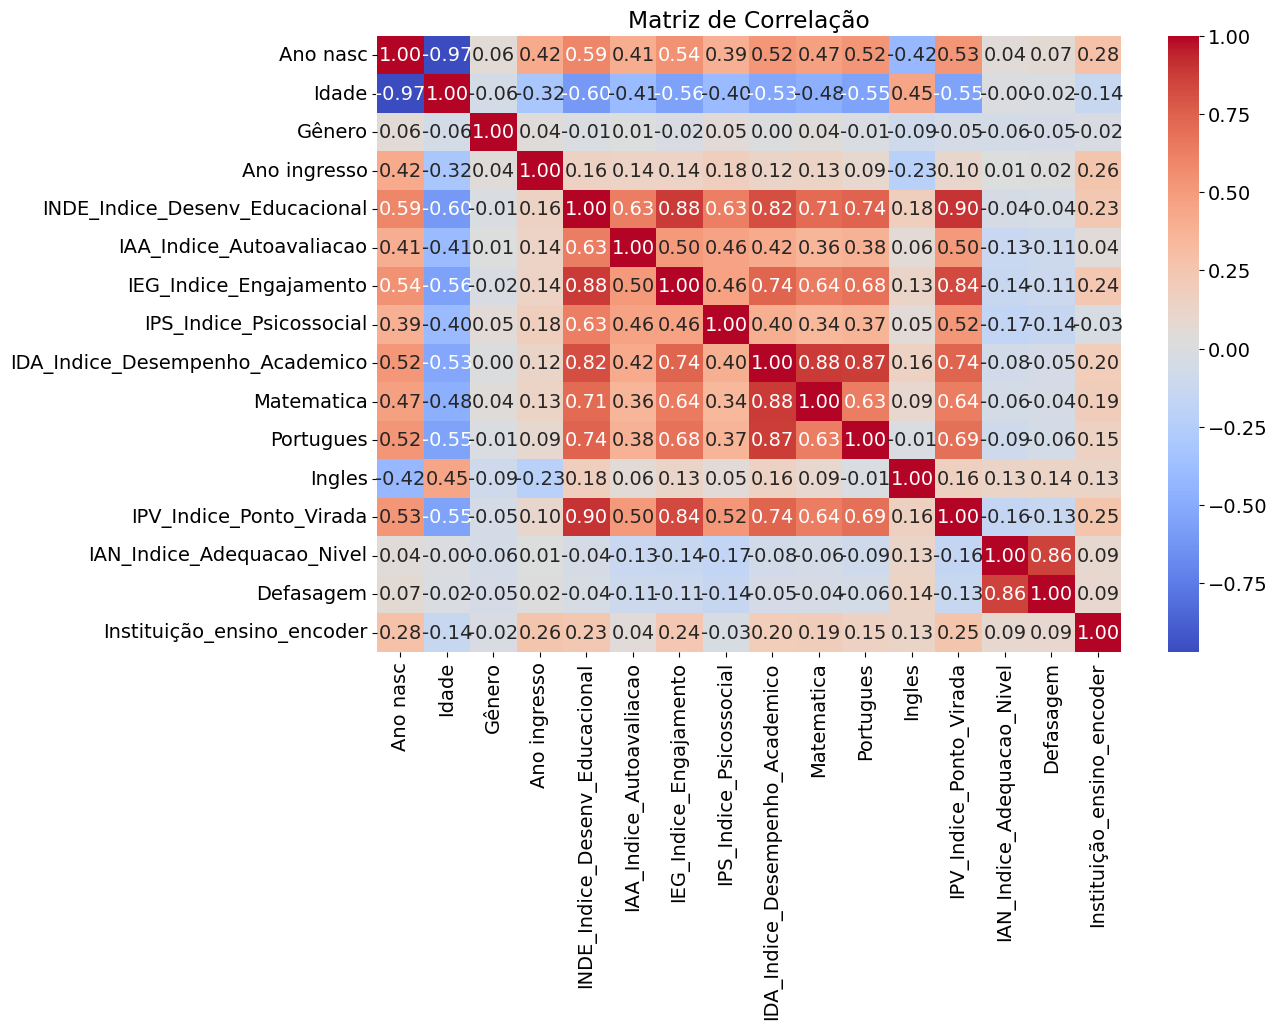

In [464]:
corr = df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de Correlação')
plt.show()

**Adequação do nível (IAN) **

1 - Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano? (Ex.: quantos alunos estão moderadamente ou severamente defasados?)

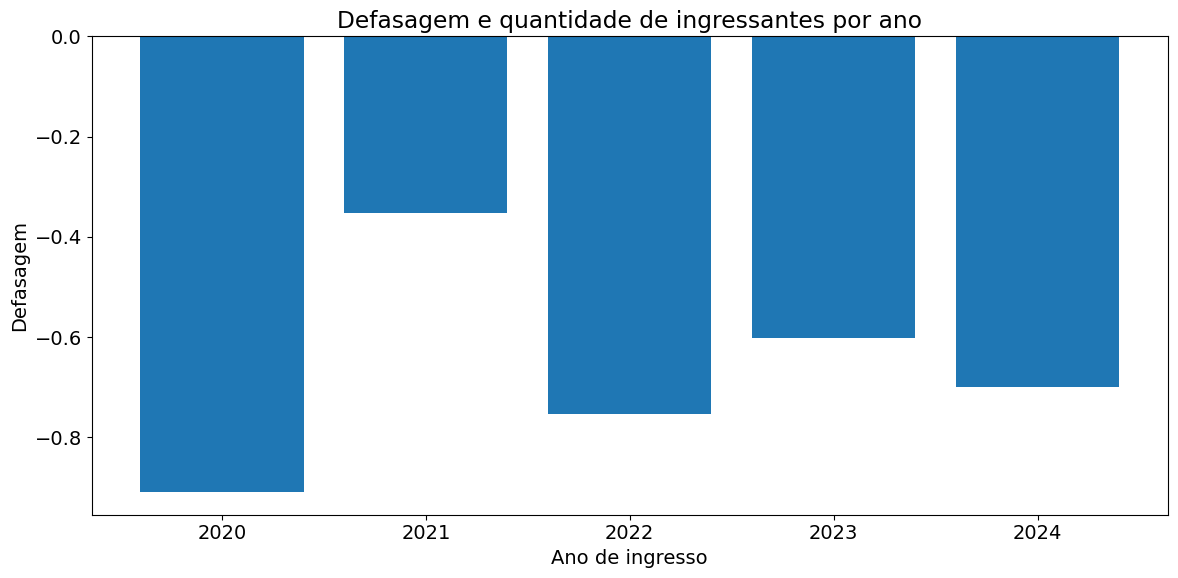

In [465]:
df['Ano ingresso'] = pd.to_numeric(df['Ano ingresso'], errors='coerce')
df['Defasagem'] = pd.to_numeric(df['Defasagem'], errors='coerce')

df_filtrado = df[df['Ano ingresso'] >= 2020]

evolucao = (
    df_filtrado
    .groupby('Ano ingresso')
    .agg(
        Defasagem=('Defasagem', 'mean'),
        Ingressantes=('Ano ingresso', 'count')
    )
    .reset_index()
    .sort_values('Ano ingresso')
)

plt.figure(figsize=(12, 6))

barras = plt.bar(
    evolucao['Ano ingresso'].astype(str),
    evolucao['Defasagem']
)

plt.xlabel('Ano de ingresso')
plt.ylabel('Defasagem')
plt.title('Defasagem e quantidade de ingressantes por ano')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Desempenho acadêmico (IDA)**

2 - O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

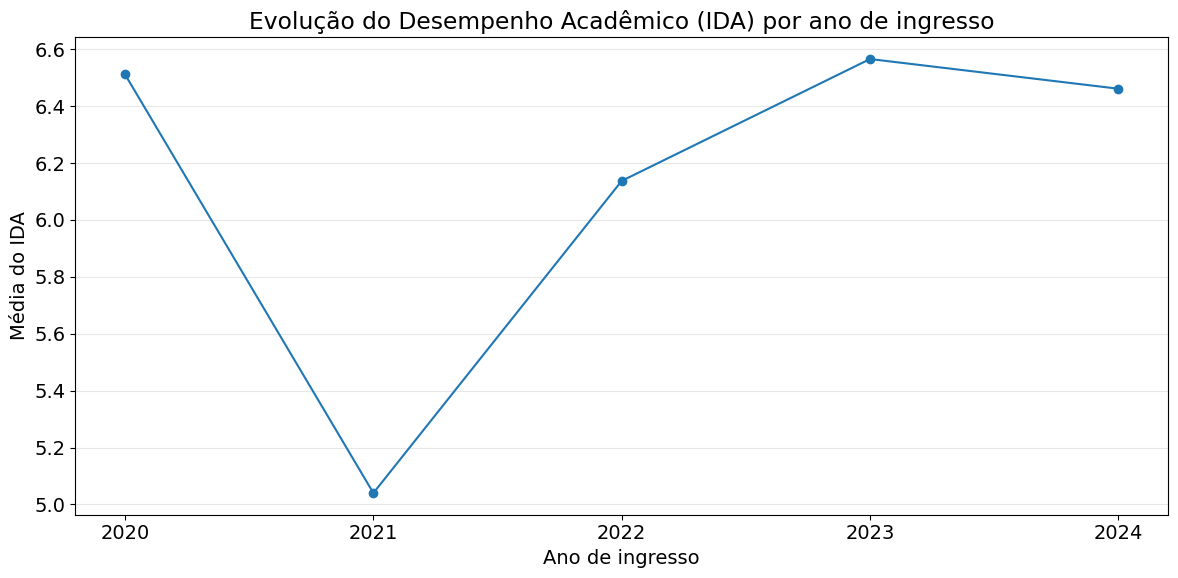

In [466]:
df['Ano ingresso'] = pd.to_numeric(df['Ano ingresso'], errors='coerce')
df['IDA_Indice_Desempenho_Academico'] = pd.to_numeric(
    df['IDA_Indice_Desempenho_Academico'],
    errors='coerce'
)

df_filtrado = df[df['Ano ingresso'] >= 2020]

evolucao = (
    df_filtrado
    .groupby('Ano ingresso')
    .agg(
        IDA=('IDA_Indice_Desempenho_Academico', 'mean'),
        Ingressantes=('Ano ingresso', 'count')
    )
    .reset_index()
    .sort_values('Ano ingresso')
)

# Gráfico
plt.figure(figsize=(12, 6))

plt.plot(
    evolucao['Ano ingresso'],
    evolucao['IDA'],
    marker='o'
)

plt.xlabel('Ano de ingresso')
plt.ylabel('Média do IDA')
plt.title('Evolução do Desempenho Acadêmico (IDA) por ano de ingresso')

plt.xticks(evolucao['Ano ingresso'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Engajamento nas atividades (IEG) **

3 - O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

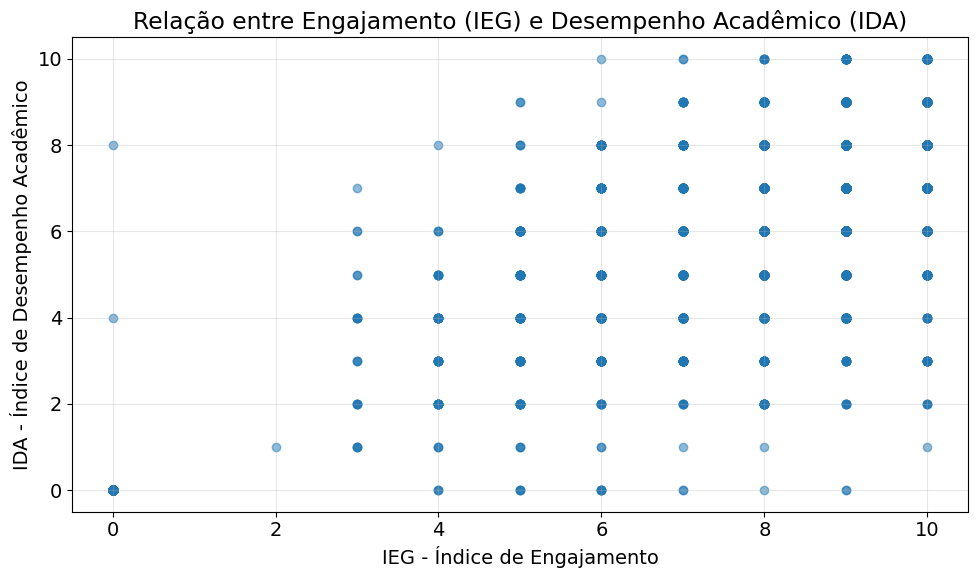

In [467]:
df['IEG_Indice_Engajamento'] = pd.to_numeric(
    df['IEG_Indice_Engajamento'],
    errors='coerce'
)

df['IDA_Indice_Desempenho_Academico'] = pd.to_numeric(
    df['IDA_Indice_Desempenho_Academico'],
    errors='coerce'
)

df['IPV_Indice_Ponto_Virada'] = pd.to_numeric(
    df['IPV_Indice_Ponto_Virada'],
    errors='coerce'
)

plt.figure(figsize=(10, 6))

plt.scatter(
    df['IEG_Indice_Engajamento'],
    df['IDA_Indice_Desempenho_Academico'],
    alpha=0.5
)

plt.xlabel('IEG - Índice de Engajamento')
plt.ylabel('IDA - Índice de Desempenho Acadêmico')
plt.title('Relação entre Engajamento (IEG) e Desempenho Acadêmico (IDA)')

plt.grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.show()

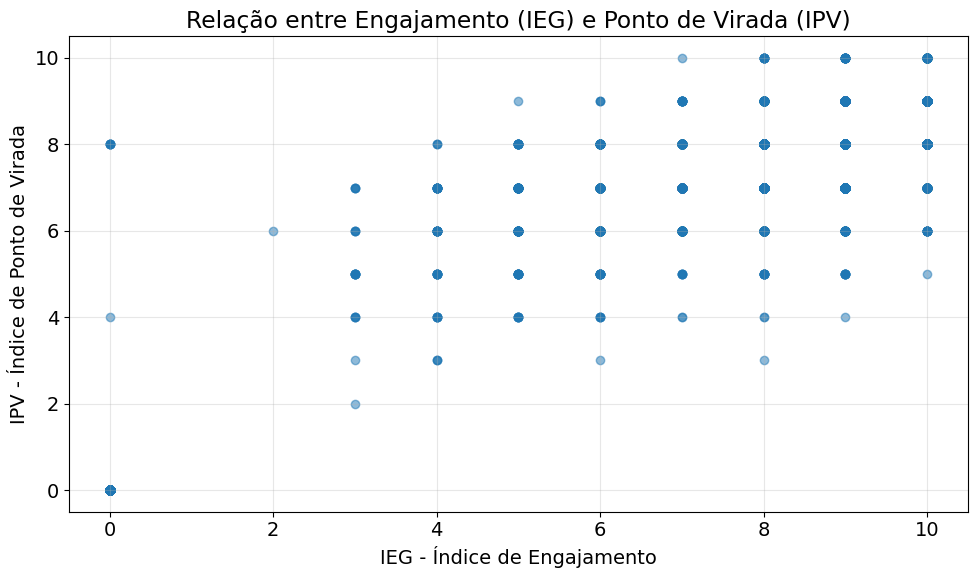

In [468]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['IEG_Indice_Engajamento'],
    df['IPV_Indice_Ponto_Virada'],
    alpha=0.5
)

plt.xlabel('IEG - Índice de Engajamento')
plt.ylabel('IPV - Índice de Ponto de Virada')
plt.title('Relação entre Engajamento (IEG) e Ponto de Virada (IPV)')

plt.grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.show()

In [469]:
correlacao = df[
    [
        'IEG_Indice_Engajamento',
        'IDA_Indice_Desempenho_Academico',
        'IPV_Indice_Ponto_Virada'
    ]
].corr()

correlacao

,IEG_Indice_Engajamento,IDA_Indice_Desempenho_Academico,IPV_Indice_Ponto_Virada
IEG_Indice_Engajamento,1.000000,0.737823,0.837203
IDA_Indice_Desempenho_Academico,0.737823,1.000000,0.738303
IPV_Indice_Ponto_Virada,0.837203,0.738303,1.000000


In [470]:
print(
    'Correlação IEG x IDA:',
    df['IEG_Indice_Engajamento'].corr(
        df['IDA_Indice_Desempenho_Academico']
    )
)

print(
    'Correlação IEG x IPV:',
    df['IEG_Indice_Engajamento'].corr(
        df['IPV_Indice_Ponto_Virada']
    )
)

Correlação IEG x IDA: 0.7378229734939782
Correlação IEG x IPV: 0.8372027554470342


**Autoavaliação (IAA) **

4 - As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

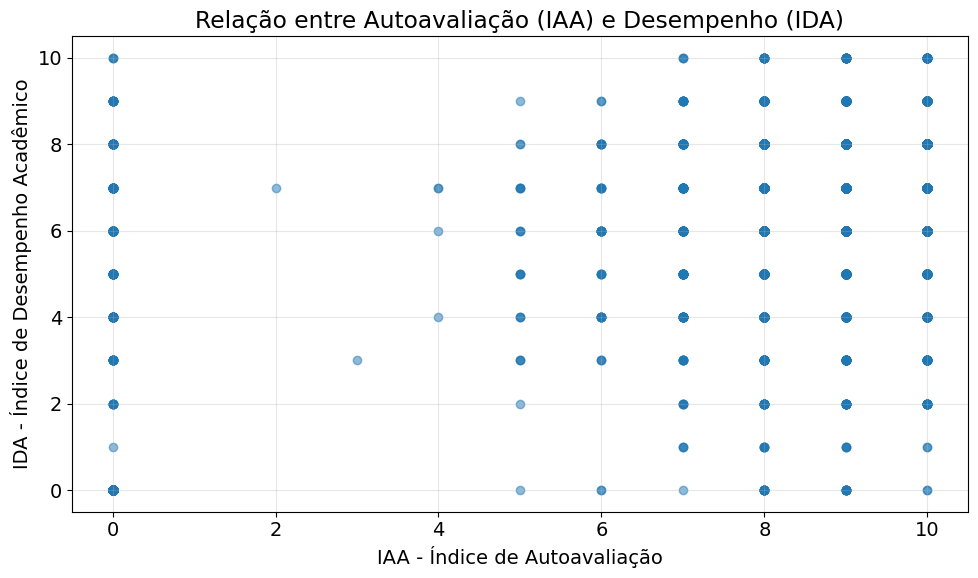

In [471]:
df['IAA_Indice_Autoavaliacao'] = pd.to_numeric(
    df['IAA_Indice_Autoavaliacao'],
    errors='coerce'
)

df['IDA_Indice_Desempenho_Academico'] = pd.to_numeric(
    df['IDA_Indice_Desempenho_Academico'],
    errors='coerce'
)

df['IEG_Indice_Engajamento'] = pd.to_numeric(
    df['IEG_Indice_Engajamento'],
    errors='coerce'
)

plt.figure(figsize=(10, 6))

plt.scatter(
    df['IAA_Indice_Autoavaliacao'],
    df['IDA_Indice_Desempenho_Academico'],
    alpha=0.5
)

plt.xlabel('IAA - Índice de Autoavaliação')
plt.ylabel('IDA - Índice de Desempenho Acadêmico')
plt.title('Relação entre Autoavaliação (IAA) e Desempenho (IDA)')

plt.grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.show()

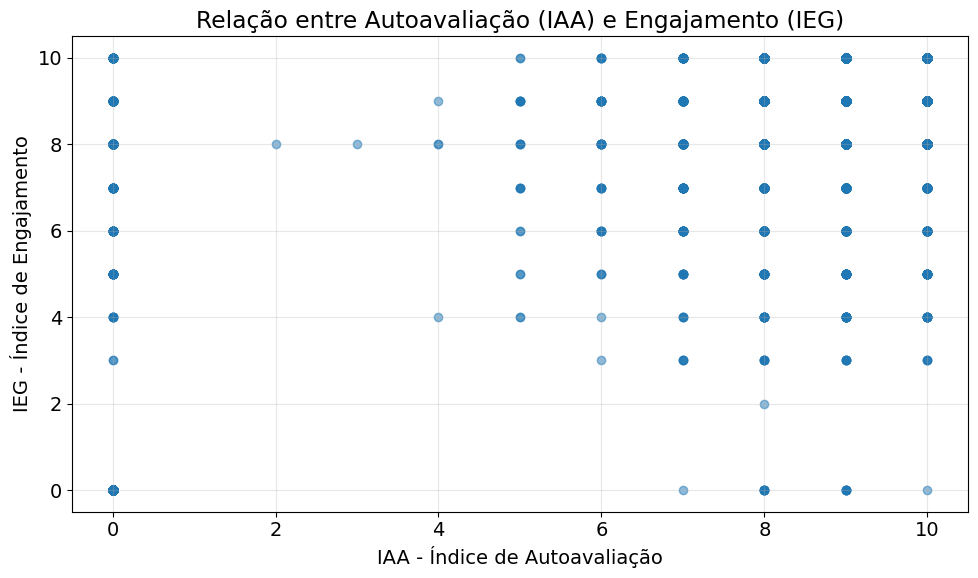

In [472]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['IAA_Indice_Autoavaliacao'],
    df['IEG_Indice_Engajamento'],
    alpha=0.5
)

plt.xlabel('IAA - Índice de Autoavaliação')
plt.ylabel('IEG - Índice de Engajamento')
plt.title('Relação entre Autoavaliação (IAA) e Engajamento (IEG)')

plt.grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.show()

In [473]:
print(
    'Correlação IAA x IDA:',
    df['IAA_Indice_Autoavaliacao'].corr(
        df['IDA_Indice_Desempenho_Academico']
    )
)

print(
    'Correlação IAA x IEG:',
    df['IAA_Indice_Autoavaliacao'].corr(
        df['IEG_Indice_Engajamento']
    )
)

Correlação IAA x IDA: 0.4160560215335003
Correlação IAA x IEG: 0.5037666049723332


In [474]:
correlacao = df[
    [
        'IAA_Indice_Autoavaliacao',
        'IDA_Indice_Desempenho_Academico',
        'IEG_Indice_Engajamento'
    ]
].corr()

correlacao

,IAA_Indice_Autoavaliacao,IDA_Indice_Desempenho_Academico,IEG_Indice_Engajamento
IAA_Indice_Autoavaliacao,1.000000,0.416056,0.503767
IDA_Indice_Desempenho_Academico,0.416056,1.000000,0.737823
IEG_Indice_Engajamento,0.503767,0.737823,1.000000


**Aspectos psicossociais (IPS) **

5 - Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

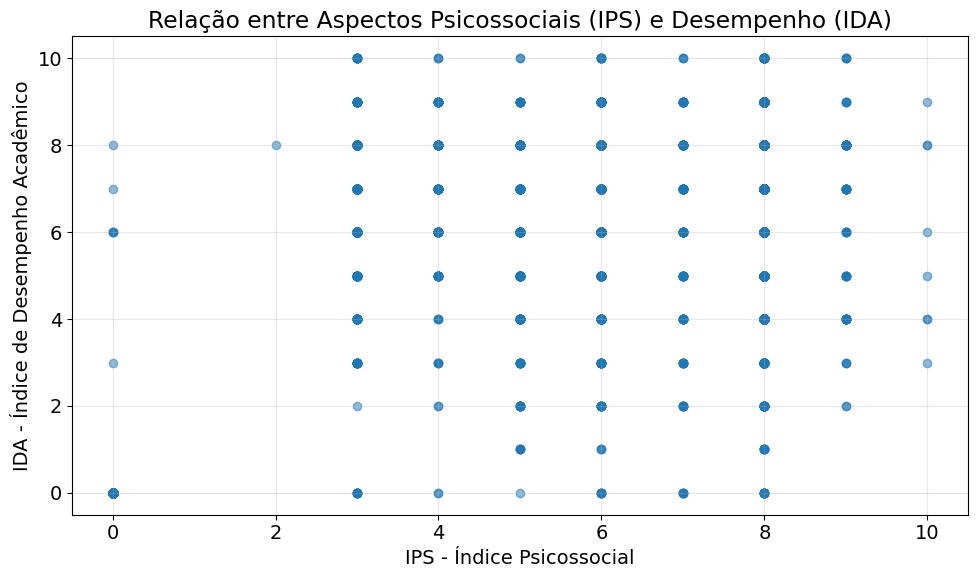

In [475]:
df['IPS_Indice_Psicossocial'] = pd.to_numeric(
    df['IPS_Indice_Psicossocial'],
    errors='coerce'
)

df['IDA_Indice_Desempenho_Academico'] = pd.to_numeric(
    df['IDA_Indice_Desempenho_Academico'],
    errors='coerce'
)

df['IEG_Indice_Engajamento'] = pd.to_numeric(
    df['IEG_Indice_Engajamento'],
    errors='coerce'
)

plt.figure(figsize=(10, 6))

plt.scatter(
    df['IPS_Indice_Psicossocial'],
    df['IDA_Indice_Desempenho_Academico'],
    alpha=0.5
)

plt.xlabel('IPS - Índice Psicossocial')
plt.ylabel('IDA - Índice de Desempenho Acadêmico')
plt.title('Relação entre Aspectos Psicossociais (IPS) e Desempenho (IDA)')

plt.grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.show()

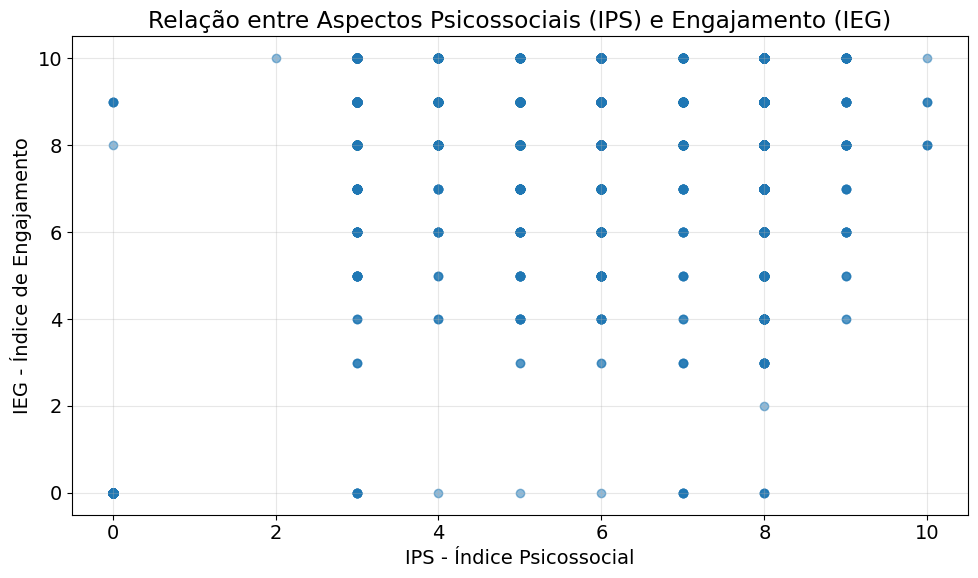

In [476]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['IPS_Indice_Psicossocial'],
    df['IEG_Indice_Engajamento'],
    alpha=0.5
)

plt.xlabel('IPS - Índice Psicossocial')
plt.ylabel('IEG - Índice de Engajamento')
plt.title('Relação entre Aspectos Psicossociais (IPS) e Engajamento (IEG)')

plt.grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.show()

In [477]:
print(
    'Correlação IPS x IDA:',
    df['IPS_Indice_Psicossocial'].corr(
        df['IDA_Indice_Desempenho_Academico']
    )
)

print(
    'Correlação IPS x IEG:',
    df['IPS_Indice_Psicossocial'].corr(
        df['IEG_Indice_Engajamento']
    )
)

Correlação IPS x IDA: 0.3998672644863968
Correlação IPS x IEG: 0.46392140574897484


In [478]:
correlacao = df[
    [
        'IPS_Indice_Psicossocial',
        'IDA_Indice_Desempenho_Academico',
        'IEG_Indice_Engajamento'
    ]
].corr()

correlacao

,IPS_Indice_Psicossocial,IDA_Indice_Desempenho_Academico,IEG_Indice_Engajamento
IPS_Indice_Psicossocial,1.000000,0.399867,0.463921
IDA_Indice_Desempenho_Academico,0.399867,1.000000,0.737823
IEG_Indice_Engajamento,0.463921,0.737823,1.000000


**Ponto de virada (IPV)**

7 - Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

In [479]:
correlacao_ipv = df[
    [
        'IPV_Indice_Ponto_Virada',
        'IDA_Indice_Desempenho_Academico',
        'IEG_Indice_Engajamento',
        'IAA_Indice_Autoavaliacao',
        'IPS_Indice_Psicossocial',
        'IAN_Indice_Adequacao_Nivel'
    ]
].corr()['IPV_Indice_Ponto_Virada'].sort_values(ascending=False)

print(correlacao_ipv)

IPV_Indice_Ponto_Virada            1.000000
IEG_Indice_Engajamento             0.837203
IDA_Indice_Desempenho_Academico    0.738303
IPS_Indice_Psicossocial            0.515824
IAA_Indice_Autoavaliacao           0.500795
IAN_Indice_Adequacao_Nivel        -0.158922
Name: IPV_Indice_Ponto_Virada, dtype: float64


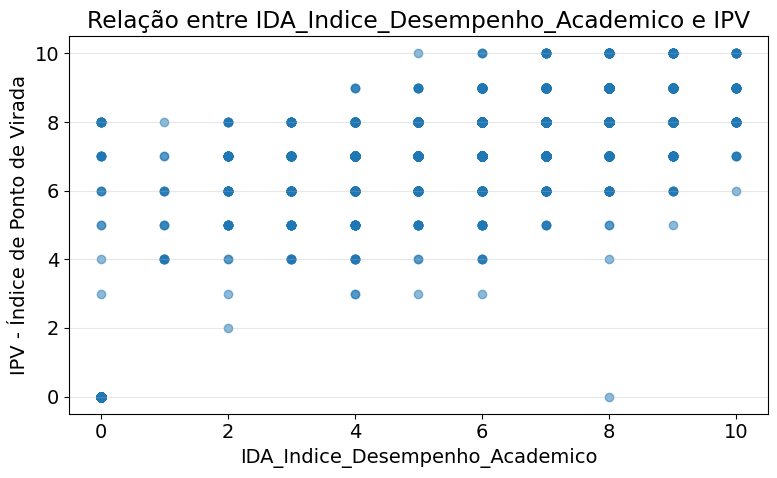

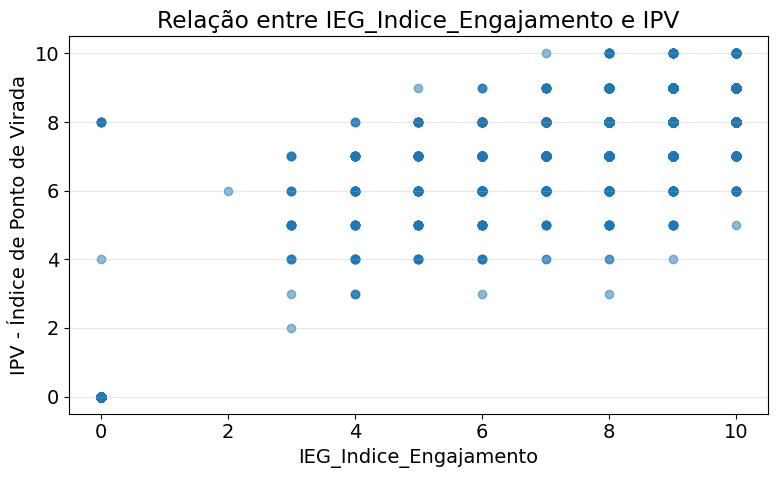

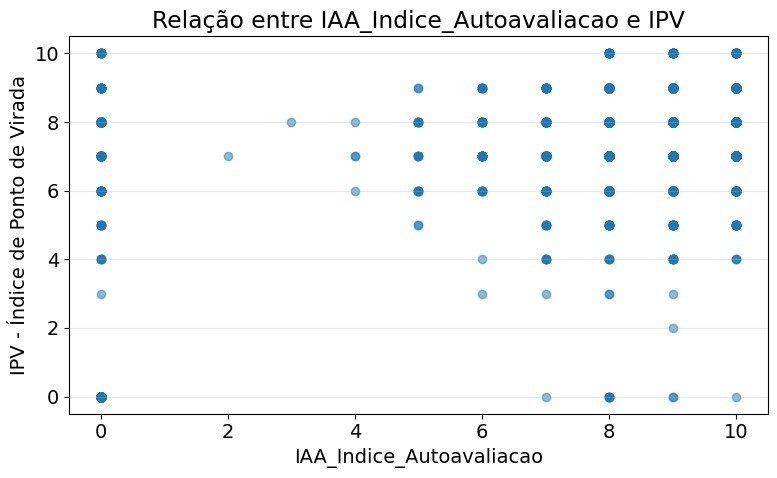

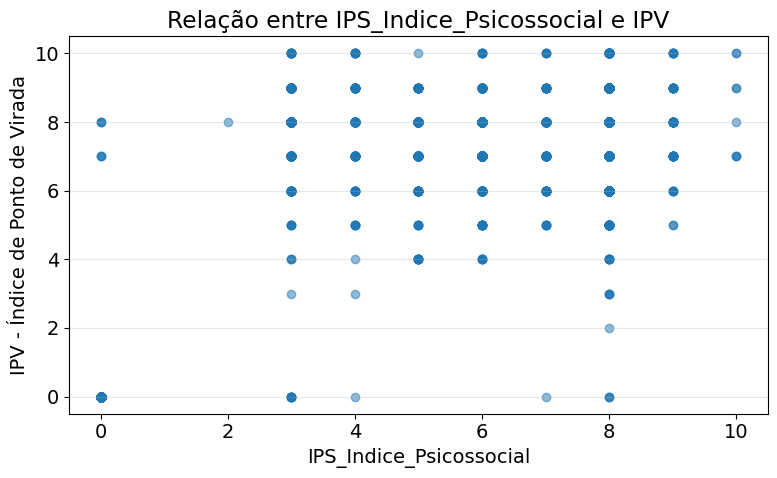

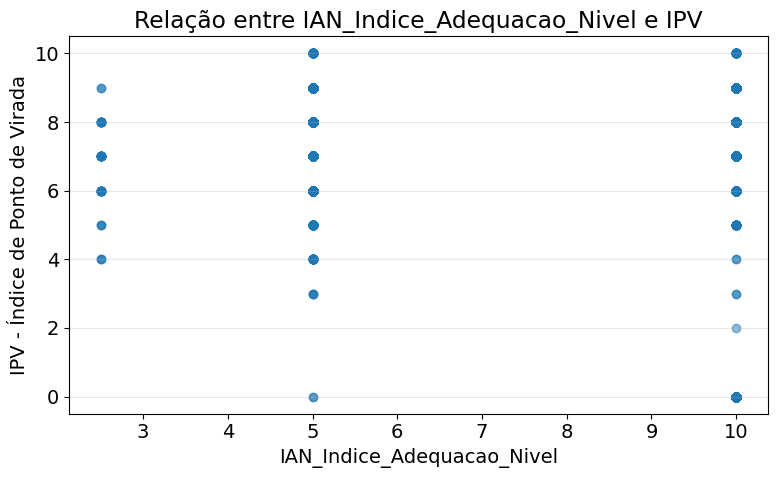

In [480]:
variaveis = [
    'IDA_Indice_Desempenho_Academico',
    'IEG_Indice_Engajamento',
    'IAA_Indice_Autoavaliacao',
    'IPS_Indice_Psicossocial',
    'IAN_Indice_Adequacao_Nivel'
]

for variavel in variaveis:
    plt.figure(figsize=(8, 5))

    plt.scatter(
        df[variavel],
        df['IPV_Indice_Ponto_Virada'],
        alpha=0.5
    )

    plt.xlabel(variavel)
    plt.ylabel('IPV - Índice de Ponto de Virada')
    plt.title(f'Relação entre {variavel} e IPV')
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

**Multidimensionalidade dos indicadores**

8 - Quais combinações de indicadores (IDA + IEG + IPS) elevam mais a nota global do aluno (INDE)?

In [481]:
correlacao_inde = df[
    [
        'INDE_Indice_Desenv_Educacional',
        'IDA_Indice_Desempenho_Academico',
        'IEG_Indice_Engajamento',
        'IPS_Indice_Psicossocial'
    ]
].corr()['INDE_Indice_Desenv_Educacional'].sort_values(ascending=False)

print(correlacao_inde)

INDE_Indice_Desenv_Educacional     1.000000
IEG_Indice_Engajamento             0.880187
IDA_Indice_Desempenho_Academico    0.815869
IPS_Indice_Psicossocial            0.625292
Name: INDE_Indice_Desenv_Educacional, dtype: float64


In [482]:
df['IDA_nivel'] = pd.qcut(
    df['IDA_Indice_Desempenho_Academico'],
    3,
    labels=['Baixo', 'Médio', 'Alto']
)

df['IEG_nivel'] = pd.qcut(
    df['IEG_Indice_Engajamento'],
    3,
    labels=['Baixo', 'Médio', 'Alto']
)

df['IPS_nivel'] = pd.qcut(
    df['IPS_Indice_Psicossocial'],
    3,
    labels=['Baixo', 'Médio', 'Alto']
)

In [483]:
combinacoes = (
    df.groupby(
        ['IDA_nivel', 'IEG_nivel', 'IPS_nivel'],
        observed=True
    )['INDE_Indice_Desenv_Educacional']
    .mean()
    .reset_index()
    .sort_values(
        'INDE_Indice_Desenv_Educacional',
        ascending=False
    )
)

print(combinacoes.head(10))

   IDA_nivel IEG_nivel IPS_nivel  INDE_Indice_Desenv_Educacional
26      Alto      Alto      Alto                        8.875000
23      Alto     Médio      Alto                        8.750000
14     Médio     Médio      Alto                        8.500000
25      Alto      Alto     Médio                        8.462312
17     Médio      Alto      Alto                        8.400000
24      Alto      Alto     Baixo                        8.215686
20      Alto     Baixo      Alto                        8.166667
22      Alto     Médio     Médio                        8.154545
16     Médio      Alto     Médio                        7.931624
21      Alto     Médio     Baixo                        7.915254


**Insights e criatividade**

11 - Você pode adicionar mais insights e pontos de vista não abordados nas perguntas, utilize a criatividade e a análise dos dados para trazer sugestões para a Passos Mágicos.

A análise dos dados permite identificar alguns insights adicionais que podem contribuir para o acompanhamento dos alunos pela Passos Mágicos. Um dos principais pontos observados é a importância do engajamento, representado pelo IEG. Esse indicador apresentou forte associação tanto com o Ponto de Virada (IPV), com correlação de 0,84, quanto com o índice global de desenvolvimento educacional (INDE), com correlação de 0,88. Isso sugere que o acompanhamento do engajamento pode ser uma dimensão importante para identificar diferentes perfis de alunos e direcionar ações de acompanhamento.

Outro insight está relacionado à análise conjunta dos indicadores. A combinação de IDA alto, IEG alto e IPS alto apresentou a maior média de INDE entre as combinações analisadas, com 8,88. Isso reforça a importância de uma visão multidimensional do aluno, considerando não apenas seu desempenho acadêmico, mas também seu engajamento e seus aspectos psicossociais.

Também seria interessante utilizar os dados para criar perfis de alunos. Por exemplo, alunos com alto engajamento e baixo desempenho acadêmico podem necessitar de estratégias diferentes daqueles que apresentam baixo engajamento e baixo desempenho. Da mesma forma, alunos com bom desempenho, mas baixo engajamento, podem representar um grupo que merece acompanhamento para evitar uma possível deterioração futura de seus resultados.

Os aspectos psicossociais também merecem atenção. O IPS apresentou correlação positiva com o IDA (0,40), o IEG (0,46) e o INDE (0,63). Embora essas relações não permitam afirmar causalidade, elas indicam que fatores psicossociais estão associados a outras dimensões importantes do desenvolvimento dos alunos e, portanto, podem ser considerados conjuntamente nas análises.

Outro possível avanço seria transformar a análise atual em um sistema de acompanhamento contínuo. Em vez de analisar somente médias gerais, a organização poderia acompanhar a evolução de cada aluno ao longo dos anos, identificando mudanças nos indicadores e possíveis situações de atenção. Isso permitiria observar, por exemplo, quando um aluno apresenta queda de engajamento, desempenho ou aspectos psicossociais e verificar se essa mudança é acompanhada por alterações em outros indicadores.

Por fim, os resultados mostram que uma análise baseada apenas em um indicador pode ocultar informações importantes. A utilização conjunta de IDA, IEG, IPS, IAA, IPV e IAN permite construir uma visão mais ampla da trajetória educacional dos alunos. Como próximo passo, seria possível desenvolver modelos de classificação ou previsão para identificar perfis de maior risco e apoiar a definição de ações pedagógicas e de acompanhamento mais personalizadas.

É importante destacar que as correlações encontradas representam associações entre os indicadores e não comprovam relações de causa e efeito. Para avaliar mudanças ao longo do tempo e identificar possíveis fatores que antecedem alterações no desempenho, seria necessário possuir observações dos mesmos alunos em diferentes períodos.


In [484]:
from sklearn.model_selection import train_test_split

In [485]:
df.columns.to_list()

['Ano nasc',
 'Idade',
 'Gênero',
 'Ano ingresso',
 'INDE_Indice_Desenv_Educacional',
 'IAA_Indice_Autoavaliacao',
 'IEG_Indice_Engajamento',
 'IPS_Indice_Psicossocial',
 'IDA_Indice_Desempenho_Academico',
 'Matematica',
 'Portugues',
 'Ingles',
 'IPV_Indice_Ponto_Virada',
 'IAN_Indice_Adequacao_Nivel',
 'Defasagem',
 'Instituição_ensino_encoder',
 'IDA_nivel',
 'IEG_nivel',
 'IPS_nivel']

In [486]:
print(df.sample(frac=1, random_state=42).head(10))

     Ano nasc  Idade  Gênero  Ano ingresso  INDE_Indice_Desenv_Educacional  IAA_Indice_Autoavaliacao  IEG_Indice_Engajamento  IPS_Indice_Psicossocial  IDA_Indice_Desempenho_Academico  Matematica  Portugues  Ingles  IPV_Indice_Ponto_Virada  IAN_Indice_Adequacao_Nivel  Defasagem  Instituição_ensino_encoder IDA_nivel IEG_nivel IPS_nivel
347      2013     10       0          2022                             8.0                      10.0                     9.0                      8.0                              8.0         7.0        8.0     0.0                      8.0                         5.0         -1                          11      Alto     Médio     Médio
256      2008     14       0          2018                             5.0                       0.0                     6.0                      6.0                              4.0         4.0        5.0     2.0                      7.0                         5.0         -1                           4     Baixo     Baixo   

In [487]:
X = df.drop(['IDA_nivel', 'IEG_nivel', 'IPS_nivel', 'Defasagem'], axis=1)

In [488]:
print(X.head(10))

   Ano nasc  Idade  Gênero  Ano ingresso  INDE_Indice_Desenv_Educacional  IAA_Indice_Autoavaliacao  IEG_Indice_Engajamento  IPS_Indice_Psicossocial  IDA_Indice_Desempenho_Academico  Matematica  Portugues  Ingles  IPV_Indice_Ponto_Virada  IAN_Indice_Adequacao_Nivel  Instituição_ensino_encoder
0      2003     19       0          2016                             6.0                       8.0                     4.0                      6.0                              4.0         3.0        4.0     6.0                      7.0                         5.0                           4
1      2005     17       0          2017                             7.0                       9.0                     5.0                      6.0                              7.0         6.0        4.0    10.0                      7.0                        10.0                          12
2      2005     17       0          2016                             7.0                       0.0                     8.

In [489]:
y = df['Defasagem']

In [490]:
print(y.head(10))

0   -1
1    0
2    0
3    0
4    0
5   -1
6   -1
7   -1
8   -1
9   -1
Name: Defasagem, dtype: int64


In [491]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [492]:
from sklearn.linear_model import LogisticRegression

In [493]:
lr = LogisticRegression()

In [494]:
lr.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [495]:
accuracy = lr.score(X_test, y_test)
print(f'accuracy: {accuracy}')

accuracy: 0.806930693069307


In [496]:
y_pred = lr.predict(X_test)

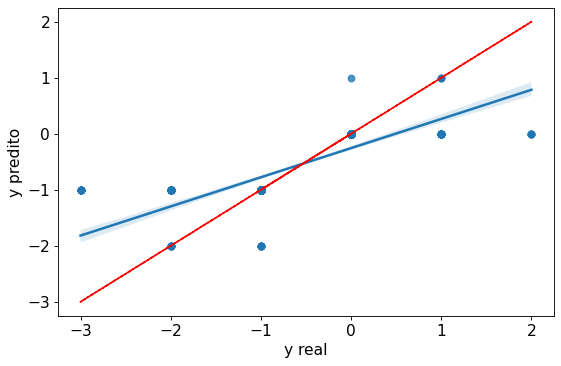

In [497]:
fig = plt.figure(figsize=(8, 5), dpi=80)
plt.rcParams.update({'font.size': 14})
ax = sns.regplot(x = y_test, y = y_pred)
ax.set(xlabel='y real', ylabel='y predito')
ax = plt.plot(y_test, y_test, '--r')
plt.show()

In [498]:
from sklearn.neighbors import KNeighborsClassifier

In [499]:
knn = KNeighborsClassifier(n_neighbors=3)

In [500]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [501]:
accuracy_knn = knn.score(X_test, y_test)
print(f'accuracy: {accuracy_knn}')


accuracy: 0.7904290429042904


In [502]:
from sklearn.tree import DecisionTreeRegressor

In [503]:
model_dtr = DecisionTreeRegressor(random_state=42, max_depth=10)
model_dtr.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [504]:
y_pred_model_dtr = model_dtr.predict(X_test)

In [505]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [506]:
MAE = mean_absolute_error(y_test, y_pred_model_dtr)
MSE = mean_squared_error(y_test, y_pred_model_dtr)
r2 = r2_score(y_test, y_pred_model_dtr)

print('MAE', MAE)
print('MSE', MSE)
print('r²', r2)

MAE 0.2388489677690587
MSE 0.1741936558441354
r² 0.7623198681836605


In [507]:
import joblib

In [508]:
joblib.dump(lr, 'modelo_defasagem.joblib')

['modelo_defasagem.joblib']

In [509]:
modelo = joblib.load('modelo_defasagem.joblib')
print(modelo)

LogisticRegression()


In [510]:
colunas_modelo = X.columns.tolist()
joblib.dump(colunas_modelo, 'colunas_modelo.joblib')

['colunas_modelo.joblib']

In [511]:
print(colunas_modelo)

['Ano nasc', 'Idade', 'Gênero', 'Ano ingresso', 'INDE_Indice_Desenv_Educacional', 'IAA_Indice_Autoavaliacao', 'IEG_Indice_Engajamento', 'IPS_Indice_Psicossocial', 'IDA_Indice_Desempenho_Academico', 'Matematica', 'Portugues', 'Ingles', 'IPV_Indice_Ponto_Virada', 'IAN_Indice_Adequacao_Nivel', 'Instituição_ensino_encoder']


In [512]:
print(X.head())

   Ano nasc  Idade  Gênero  Ano ingresso  INDE_Indice_Desenv_Educacional  IAA_Indice_Autoavaliacao  IEG_Indice_Engajamento  IPS_Indice_Psicossocial  IDA_Indice_Desempenho_Academico  Matematica  Portugues  Ingles  IPV_Indice_Ponto_Virada  IAN_Indice_Adequacao_Nivel  Instituição_ensino_encoder
0      2003     19       0          2016                             6.0                       8.0                     4.0                      6.0                              4.0         3.0        4.0     6.0                      7.0                         5.0                           4
1      2005     17       0          2017                             7.0                       9.0                     5.0                      6.0                              7.0         6.0        4.0    10.0                      7.0                        10.0                          12
2      2005     17       0          2016                             7.0                       0.0                     8.

In [513]:
print(X.dtypes)

Ano nasc                             int64
Idade                                int64
Gênero                               int64
Ano ingresso                         int64
INDE_Indice_Desenv_Educacional     float64
IAA_Indice_Autoavaliacao           float64
IEG_Indice_Engajamento             float64
IPS_Indice_Psicossocial            float64
IDA_Indice_Desempenho_Academico    float64
Matematica                         float64
Portugues                          float64
Ingles                             float64
IPV_Indice_Ponto_Virada            float64
IAN_Indice_Adequacao_Nivel         float64
Instituição_ensino_encoder           int64
dtype: object


In [514]:
print(X.describe().T)

                                  count         mean       std     min     25%     50%     75%     max
Ano nasc                         3030.0  2010.454455  3.314445  1996.0  2008.0  2011.0  2013.0  2017.0
Idade                            3030.0    12.527063  3.299273     7.0    10.0    12.0    15.0    27.0
Gênero                           3030.0     0.463366  0.498738     0.0     0.0     0.0     1.0     1.0
Ano ingresso                     3030.0  2021.563696  1.822171  2016.0  2021.0  2022.0  2023.0  2024.0
INDE_Indice_Desenv_Educacional   3030.0     6.834653  2.003642     0.0     7.0     7.0     8.0    10.0
IAA_Indice_Autoavaliacao         3030.0     7.557426  3.172675     0.0     8.0     9.0    10.0    10.0
IEG_Indice_Engajamento           3030.0     7.771617  2.494362     0.0     7.0     8.0     9.0    10.0
IPS_Indice_Psicossocial          3030.0     6.200660  2.345384     0.0     5.0     7.0     8.0    10.0
IDA_Indice_Desempenho_Academico  3030.0     5.994719  2.433257     0.0   

In [515]:
print(sorted(X['IAN_Indice_Adequacao_Nivel'].unique()))

[np.float64(2.5), np.float64(5.0), np.float64(10.0)]
